# 1. Data Loading

In [ ]:
# ============================================================
# CELL 1 — Environment Setup + Reproducibility + Config
# ============================================================

import os, glob, random, json, time
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd

import torch
from torch.utils.data import Dataset, DataLoader

# ----------------------------
# 1) Reproducibility / Seed
# ----------------------------
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # deterministic behavior (slower but reproducible)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
seed_everything(SEED)

# ----------------------------
# 2) Device
# ----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ----------------------------
# 3) Config
# ----------------------------
@dataclass
class CFG:
    # Set this to your dataset root folder
    # Kaggle example: "/kaggle/input/sen2fire/Sen2Fire"
    # Local example:  r"D:\datasets\Sen2Fire\Sen2Fire"
    DATA_ROOT: str = "/kaggle/input/sen2fire/Sen2Fire"

    # Sen2Fire naming in the dataset release (commonly: scene1..scene4)
    SCENES: Tuple[str, ...] = ("scene1", "scene2", "scene3", "scene4")

    # file extension for patches
    PATCH_EXT: str = ".npz"

    # Paper split: train = scene1+scene2, val = scene3, test = scene4
    TRAIN_SCENES: Tuple[str, ...] = ("scene1", "scene2")
    VAL_SCENES: Tuple[str, ...] = ("scene3",)
    TEST_SCENES: Tuple[str, ...] = ("scene4",)

    # If you want a quick demo run:
    USE_SMALL_SAMPLE: bool = True
    SMALL_SAMPLE_TRAIN: int = 200
    SMALL_SAMPLE_VAL: int = 60
    SMALL_SAMPLE_TEST: int = 60

    # For debug prints
    VERBOSE: bool = True

cfg = CFG()

# ----------------------------
# 4) Helper: list patch files
# ----------------------------
def list_scene_files(data_root: str, scene_name: str, ext: str = ".npz") -> List[str]:
    scene_dir = os.path.join(data_root, scene_name)
    pattern = os.path.join(scene_dir, f"*{ext}")
    files = sorted(glob.glob(pattern))
    return files

def assert_exists(path: str, name: str = "path") -> None:
    if not os.path.exists(path):
        raise FileNotFoundError(f"{name} not found: {path}")

assert_exists(cfg.DATA_ROOT, "cfg.DATA_ROOT")
print("DATA_ROOT OK:", cfg.DATA_ROOT)

# ----------------------------
# 5) Helper: inspect npz structure
# ----------------------------
def inspect_npz(npz_path: str, max_print: int = 20) -> Dict[str, Tuple[Tuple[int, ...], str]]:
    """
    Returns dictionary:
      key -> (shape, dtype)
    """
    with np.load(npz_path) as data:
        keys = list(data.keys())
        info = {}
        for k in keys[:max_print]:
            arr = data[k]
            info[k] = (arr.shape, str(arr.dtype))
    return info

In [8]:
# ============================================================
# CELL 2 — Build Dataset Manifest + Split + TRAIN Balancing (80/20)
# ============================================================

import os, glob
import numpy as np
import pandas as pd

# ----------------------------
# 1) Gather all files per scene
# ----------------------------
scene_to_files = {}
total = 0

for s in cfg.SCENES:
    files = list_scene_files(cfg.DATA_ROOT, s, cfg.PATCH_EXT)
    scene_to_files[s] = files
    total += len(files)
    print(f"{s}: {len(files)} patches")

print("Total patches:", total)

# ----------------------------
# 2) Create a manifest dataframe (traceability)
# ----------------------------
rows = []
for s, files in scene_to_files.items():
    for p in files:
        rows.append({"scene": s, "path": p})
manifest = pd.DataFrame(rows)

if cfg.VERBOSE:
    display(manifest.head())
    display(manifest["scene"].value_counts())

# ----------------------------
# 3) Quick sanity check: inspect one file (keys/shapes)
# ----------------------------
if total == 0:
    raise RuntimeError("No patch files found. Check cfg.DATA_ROOT and cfg.PATCH_EXT.")

sample_path = manifest.iloc[0]["path"]
print("Sample file:", sample_path)

info = inspect_npz(sample_path)
print("NPZ keys (shape, dtype):")
for k, (shape, dtype) in info.items():
    print(f"  - {k:>15s}: shape={shape}, dtype={dtype}")

# ----------------------------
# 4) Split (we keep your scene split structure intact)
# ----------------------------
train_df = manifest[manifest["scene"].isin(cfg.TRAIN_SCENES)].reset_index(drop=True)
val_df   = manifest[manifest["scene"].isin(cfg.VAL_SCENES)].reset_index(drop=True)
test_df  = manifest[manifest["scene"].isin(cfg.TEST_SCENES)].reset_index(drop=True)

print("Paper split counts:")
print("  Train:", len(train_df))
print("  Val  :", len(val_df))
print("  Test :", len(test_df))

# ----------------------------
# 5) Helpers: random sample & has_fire scan
# ----------------------------
def take_sample(df: pd.DataFrame, n: int, seed: int = 42) -> pd.DataFrame:
    if len(df) <= n:
        return df.copy()
    return df.sample(n=n, random_state=seed).reset_index(drop=True)

def patch_has_fire(npz_path: str, label_key: str = "label") -> int:
    """Fast check: does this patch contain at least 1 fire pixel?"""
    with np.load(npz_path) as data:
        if label_key not in data:
            raise KeyError(f"Label key '{label_key}' not found in {npz_path}. Available keys: {list(data.keys())}")
        y = data[label_key]
        # Handle (H,W,1)
        if y.ndim == 3 and y.shape[-1] == 1:
            y = y[..., 0]
        return int((y > 0).any())

def take_stratified_sample_train(df: pd.DataFrame, n: int, pos_ratio: float, seed: int = 42) -> pd.DataFrame:
    """
    Stratified sampling by has_fire column.
    pos_ratio: fraction of fire-containing patches (has_fire=1) in the sample.
              Example pos_ratio=0.2 means 20% fire patches, 80% no-fire patches.
    """
    if "has_fire" not in df.columns:
        raise ValueError("DataFrame must include 'has_fire' column before stratified sampling.")

    df_pos = df[df["has_fire"] == 1]
    df_neg = df[df["has_fire"] == 0]

    n_pos = int(round(n * pos_ratio))
    n_neg = n - n_pos

    # Safety handling if not enough positives/negatives
    if len(df_pos) < n_pos:
        n_pos = len(df_pos)
        n_neg = n - n_pos
    if len(df_neg) < n_neg:
        n_neg = len(df_neg)
        n_pos = n - n_neg

    pos_s = df_pos.sample(n=n_pos, random_state=seed) if n_pos > 0 else df_pos.head(0)
    neg_s = df_neg.sample(n=n_neg, random_state=seed) if n_neg > 0 else df_neg.head(0)

    out = pd.concat([pos_s, neg_s], axis=0).sample(frac=1, random_state=seed).reset_index(drop=True)
    return out

# ----------------------------
# 6) Small sample mode (TRAIN balanced 80/20, VAL/TEST natural)
# ----------------------------
TRAIN_POS_RATIO = 0.2  # 20% has_fire, 80% no-fire

if cfg.USE_SMALL_SAMPLE:
    # (A) Compute has_fire on train_df only (efficient)
    train_df = train_df.copy()
    if "has_fire" not in train_df.columns:
        train_df["has_fire"] = train_df["path"].apply(lambda p: patch_has_fire(p, label_key="label"))

    print("\nTrain has_fire distribution (FULL train_df):")
    display(train_df["has_fire"].value_counts())
    display(train_df["has_fire"].value_counts(normalize=True).rename("ratio"))

    # (B) Take stratified sample for TRAIN (80/20)
    train_df_s = take_stratified_sample_train(train_df, cfg.SMALL_SAMPLE_TRAIN, pos_ratio=TRAIN_POS_RATIO, seed=SEED)

    # (C) Val/Test are natural random samples (do not balance)
    val_df_s   = take_sample(val_df, cfg.SMALL_SAMPLE_VAL, SEED)
    test_df_s  = take_sample(test_df, cfg.SMALL_SAMPLE_TEST, SEED)

    print("\nUsing SMALL SAMPLE:")
    print("  Train:", len(train_df_s), f"(target pos_ratio={TRAIN_POS_RATIO})")
    print("  Val  :", len(val_df_s),  "(natural)")
    print("  Test :", len(test_df_s), "(natural)")

    # (D) Print actual achieved ratio in sampled TRAIN
    if "has_fire" in train_df_s.columns:
        print("\nTrain has_fire distribution (SAMPLED train_df_s):")
        display(train_df_s["has_fire"].value_counts())
        display(train_df_s["has_fire"].value_counts(normalize=True).rename("ratio"))

else:
    # Full dataset mode: no balancing here, because training strategy will be handled later by sampler/loss
    train_df_s, val_df_s, test_df_s = train_df, val_df, test_df

# ----------------------------
# 7) Store to python lists for later Dataset class
# ----------------------------
train_paths = train_df_s["path"].tolist()
val_paths   = val_df_s["path"].tolist()
test_paths  = test_df_s["path"].tolist()

# ----------------------------
# 8) Extra checks: no overlap across splits
# ----------------------------
overlap_tv = set(train_paths).intersection(set(val_paths))
overlap_tt = set(train_paths).intersection(set(test_paths))
overlap_vt = set(val_paths).intersection(set(test_paths))

print("\nOverlap checks (must be 0):")
print("  train ∩ val :", len(overlap_tv))
print("  train ∩ test:", len(overlap_tt))
print("  val   ∩ test:", len(overlap_vt))

assert len(overlap_tv) == 0 and len(overlap_tt) == 0 and len(overlap_vt) == 0, "Split leakage detected!"

# ----------------------------
# 9) Save manifest snapshots (audit trail)
# ----------------------------
OUT_DIR = "./artifacts_sen2fire"
os.makedirs(OUT_DIR, exist_ok=True)

manifest.to_csv(os.path.join(OUT_DIR, "manifest_all.csv"), index=False)
train_df_s.to_csv(os.path.join(OUT_DIR, "manifest_train.csv"), index=False)
val_df_s.to_csv(os.path.join(OUT_DIR, "manifest_val.csv"), index=False)
test_df_s.to_csv(os.path.join(OUT_DIR, "manifest_test.csv"), index=False)

print("\nSaved manifests to:", OUT_DIR)

# Optional: Save FULL train_df with has_fire (useful for analysis later)
if cfg.USE_SMALL_SAMPLE and "has_fire" in train_df.columns:
    train_df.to_csv(os.path.join(OUT_DIR, "manifest_train_full_with_has_fire.csv"), index=False)
    print("Saved FULL train manifest with has_fire to:", os.path.join(OUT_DIR, "manifest_train_full_with_has_fire.csv"))

scene1: 864 patches
scene2: 594 patches
scene3: 504 patches
scene4: 504 patches
Total patches: 2466


,scene,path
0,scene1,/kaggle/input/sen2fire/Sen2Fire/scene1/scene_1...
1,scene1,/kaggle/input/sen2fire/Sen2Fire/scene1/scene_1...
2,scene1,/kaggle/input/sen2fire/Sen2Fire/scene1/scene_1...
3,scene1,/kaggle/input/sen2fire/Sen2Fire/scene1/scene_1...
4,scene1,/kaggle/input/sen2fire/Sen2Fire/scene1/scene_1...


scene
scene1    864
scene2    594
scene3    504
scene4    504
Name: count, dtype: int64

Sample file: /kaggle/input/sen2fire/Sen2Fire/scene1/scene_1_patch_10_1.npz
NPZ keys (shape, dtype):
  -           image: shape=(12, 512, 512), dtype=int16
  -         aerosol: shape=(512, 512), dtype=float32
  -           label: shape=(512, 512), dtype=uint8
Paper split counts:
  Train: 1458
  Val  : 504
  Test : 504

Train has_fire distribution (FULL train_df):


has_fire
0    1305
1     153
Name: count, dtype: int64

has_fire
0    0.895062
1    0.104938
Name: ratio, dtype: float64


Using SMALL SAMPLE:
  Train: 200 (target pos_ratio=0.2)
  Val  : 60 (natural)
  Test : 60 (natural)

Train has_fire distribution (SAMPLED train_df_s):


has_fire
0    160
1     40
Name: count, dtype: int64

has_fire
0    0.8
1    0.2
Name: ratio, dtype: float64


Overlap checks (must be 0):
  train ∩ val : 0
  train ∩ test: 0
  val   ∩ test: 0

Saved manifests to: ./artifacts_sen2fire
Saved FULL train manifest with has_fire to: ./artifacts_sen2fire/manifest_train_full_with_has_fire.csv


# 2. Data Quality

Sample path: /kaggle/input/sen2fire/Sen2Fire/scene1/scene_1_patch_12_3.npz
Meta: {'x_key': 'image', 'y_key': 'label', 'a_key': 'aerosol', 'x_shape': (12, 512, 512), 'x_dtype': 'int16', 'y_shape': (512, 512), 'a_shape': (512, 512), 'keys': ['image', 'aerosol', 'label'], 'x_transposed_CHW_to_HWC': True}


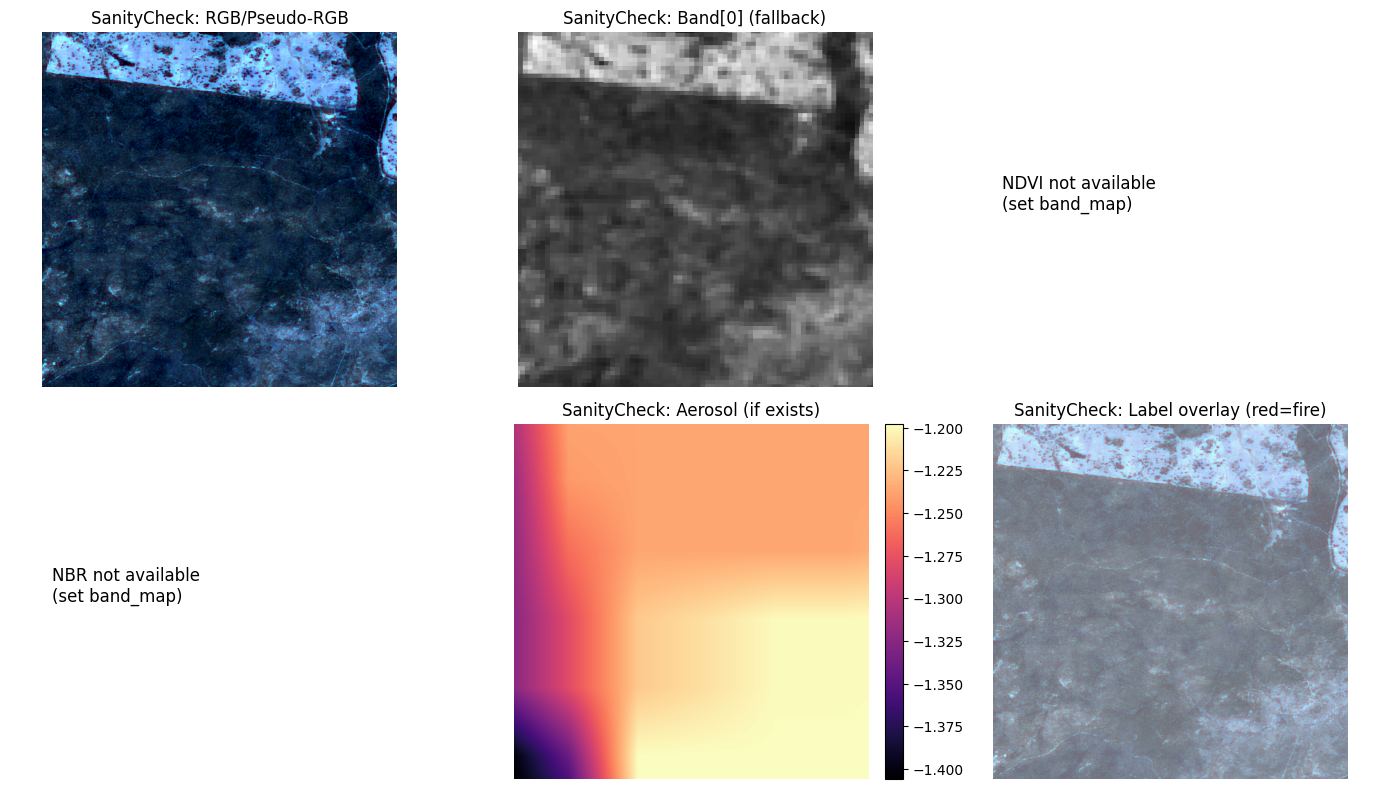

In [9]:
# ============================================================
# CELL 3 — Data Loader (1 patch) + Visualization Utilities
# Goal: verify shapes, band order, label alignment
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ---------- Helper: find likely keys ----------
def pick_key(npz_obj, candidates):
    keys = list(npz_obj.keys())
    for c in candidates:
        if c in keys:
            return c
    return None

# ---------- Helper: load one patch ----------
def load_patch(npz_path: str):
    """
    Returns:
      x: np.ndarray (H, W, C)  multispectral or composite
      y: np.ndarray (H, W)     binary mask (0/1) if exists, else None
      a: np.ndarray (H, W)     aerosol if exists, else None
      meta: dict              debugging info
    """
    with np.load(npz_path) as data:
        # Common naming guesses (you may need to adjust)
        x_key = pick_key(data, ["x", "image", "img", "s2", "sentinel2", "patch"])
        y_key = pick_key(data, ["y", "mask", "label", "labels", "gt"])
        a_key = pick_key(data, ["aerosol", "s5p", "ai", "a"])

        if x_key is None:
            raise KeyError(f"Cannot find image key in npz. Available keys: {list(data.keys())}")

        x = data[x_key]
        y = data[y_key] if y_key is not None else None
        a = data[a_key] if a_key is not None else None

        meta = {
            "x_key": x_key, "y_key": y_key, "a_key": a_key,
            "x_shape": x.shape, "x_dtype": str(x.dtype),
            "y_shape": None if y is None else y.shape,
            "a_shape": None if a is None else a.shape,
            "keys": list(data.keys())
        }

    # Normalize shape to (H, W, C)
    # Some datasets store (C, H, W)
    if x.ndim == 3 and x.shape[0] in [10, 11, 12, 13] and x.shape[0] < x.shape[-1]:
        # likely CHW -> HWC
        x = np.transpose(x, (1, 2, 0))
        meta["x_transposed_CHW_to_HWC"] = True
    else:
        meta["x_transposed_CHW_to_HWC"] = False

    # Ensure y is (H, W)
    if y is not None and y.ndim == 3:
        # sometimes stored as (H, W, 1)
        if y.shape[-1] == 1:
            y = y[..., 0]
        else:
            # fallback: take first channel
            y = y[..., 0]

    # Ensure aerosol is (H, W)
    if a is not None and a.ndim == 3:
        if a.shape[-1] == 1:
            a = a[..., 0]
        else:
            a = a[..., 0]

    return x, y, a, meta

# ---------- Helper: safe band indexing ----------
def get_band(x_hwc, idx):
    if x_hwc is None:
        return None
    if idx < 0 or idx >= x_hwc.shape[-1]:
        return None
    return x_hwc[..., idx]

# ---------- Indices: NDVI and NBR ----------
def compute_ndvi(nir, red, eps=1e-6):
    return (nir - red) / (nir + red + eps)

def compute_nbr(nir, swir, eps=1e-6):
    return (nir - swir) / (nir + swir + eps)

# ---------- Visualization ----------
def to_rgb_composite(x, r_idx, g_idx, b_idx, clip_percentiles=(2, 98)):
    """
    x: (H,W,C) float/int
    returns rgb uint8 (H,W,3)
    """
    r = get_band(x, r_idx)
    g = get_band(x, g_idx)
    b = get_band(x, b_idx)
    if (r is None) or (g is None) or (b is None):
        return None

    rgb = np.stack([r, g, b], axis=-1).astype(np.float32)

    # Percentile clipping for nicer visualization
    lo, hi = np.percentile(rgb, clip_percentiles[0]), np.percentile(rgb, clip_percentiles[1])
    rgb = np.clip((rgb - lo) / (hi - lo + 1e-6), 0, 1)
    rgb = (rgb * 255).astype(np.uint8)
    return rgb

def show_patch_views(x, y=None, a=None, band_map=None, title_prefix=""):
    """
    band_map expects indices for standard S2 bands if your x uses that order.
    Example band_map (if x is 12 bands of S2 L2A without cirrus):
      B2=0,B3=1,B4=2,B8=3,B11=10,B12=11 (THIS IS JUST EXAMPLE; MUST MATCH YOUR DATA)
    If you don't know, we'll just show first 3 bands as pseudo-RGB.
    """
    H, W, C = x.shape
    band_map = band_map or {}

    # Try to build RGB using known mapping; fallback to first 3 channels
    # NOTE: S2 true RGB uses B4,B3,B2 (red, green, blue)
    r_idx = band_map.get("B4", 0)
    g_idx = band_map.get("B3", 1)
    b_idx = band_map.get("B2", 2)

    rgb = to_rgb_composite(x, r_idx, g_idx, b_idx)
    if rgb is None:
        rgb = to_rgb_composite(x, 0, 1, 2)

    # SWIR composite often uses (B12, B8, B4) for visualization
    swir_idx = band_map.get("B12", None)
    nir_idx  = band_map.get("B8", None)
    red_idx  = band_map.get("B4", None)

    swir_rgb = None
    if (swir_idx is not None) and (nir_idx is not None) and (red_idx is not None):
        swir_rgb = to_rgb_composite(x, swir_idx, nir_idx, red_idx)

    # NDVI / NBR if possible
    ndvi = None
    nbr = None
    if (nir_idx is not None) and (red_idx is not None):
        ndvi = compute_ndvi(get_band(x, nir_idx).astype(np.float32),
                            get_band(x, red_idx).astype(np.float32))
    if (nir_idx is not None) and (swir_idx is not None):
        nbr = compute_nbr(get_band(x, nir_idx).astype(np.float32),
                          get_band(x, swir_idx).astype(np.float32))

    # Plot grid
    ncols = 3
    nrows = 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 8))
    axes = axes.ravel()

    axes[0].imshow(rgb)
    axes[0].set_title(f"{title_prefix}RGB/Pseudo-RGB")
    axes[0].axis("off")

    if swir_rgb is not None:
        axes[1].imshow(swir_rgb)
        axes[1].set_title(f"{title_prefix}SWIR composite (B12,B8,B4)")
        axes[1].axis("off")
    else:
        axes[1].imshow(x[..., 0], cmap="gray")
        axes[1].set_title(f"{title_prefix}Band[0] (fallback)")
        axes[1].axis("off")

    if ndvi is not None:
        im = axes[2].imshow(ndvi, cmap="RdYlGn")
        axes[2].set_title(f"{title_prefix}NDVI")
        axes[2].axis("off")
        plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    else:
        axes[2].text(0.1, 0.5, "NDVI not available\n(set band_map)", fontsize=12)
        axes[2].axis("off")

    if nbr is not None:
        im = axes[3].imshow(nbr, cmap="coolwarm")
        axes[3].set_title(f"{title_prefix}NBR")
        axes[3].axis("off")
        plt.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)
    else:
        axes[3].text(0.1, 0.5, "NBR not available\n(set band_map)", fontsize=12)
        axes[3].axis("off")

    if a is not None:
        im = axes[4].imshow(a, cmap="magma")
        axes[4].set_title(f"{title_prefix}Aerosol (if exists)")
        axes[4].axis("off")
        plt.colorbar(im, ax=axes[4], fraction=0.046, pad=0.04)
    else:
        axes[4].text(0.1, 0.5, "Aerosol not found\n(optional)", fontsize=12)
        axes[4].axis("off")

    # Label + overlay
    if y is not None:
        axes[5].imshow(rgb)
        axes[5].imshow(y, alpha=0.45, cmap="Reds")  # overlay
        axes[5].set_title(f"{title_prefix}Label overlay (red=fire)")
        axes[5].axis("off")
    else:
        axes[5].text(0.1, 0.5, "Label not found\n(check key names)", fontsize=12)
        axes[5].axis("off")

    plt.tight_layout()
    plt.show()


# ---------- Run sanity check on one sample ----------
# (Use train_paths / val_paths / test_paths created earlier, or your own list)

sample_path = train_paths[0] if len(train_paths) > 0 else None
print("Sample path:", sample_path)

x, y, a, meta = load_patch(sample_path)
print("Meta:", meta)

# IMPORTANT: band_map must match your dataset's channel order.
# If you don't know yet, leave empty {} first and we inspect visually.
band_map = {}  # we'll fill this after you confirm channel order
show_patch_views(x, y=y, a=a, band_map=band_map, title_prefix="SanityCheck: ")


#### Penjelasan cell 3
Sebelum masuk ke tahap training model, kami melakukan *sanity check* untuk memastikan bahwa:
1. Struktur data `.npz` terbaca dengan benar (key dan shape sesuai).
2. Citra multispektral dan label memiliki ukuran spasial yang konsisten (tidak offset).
3. Nilai data masuk akal (tidak seluruhnya nol / tidak NaN / tidak terbalik).
4. Kanal aerosol tersedia dan dapat divisualisasikan sebagai layer tambahan.

Sanity check ini penting untuk menghindari kesalahan fatal seperti:
- band/channel tertukar (misalnya red dianggap NIR)
- label bergeser atau tidak sejajar dengan citra
- data label kosong atau salah format
- perbedaan resolusi yang tidak ditangani

Dari output metadata:

- **File**: `/kaggle/input/sen2fire/Sen2Fire/scene2/...patch_4_7.npz`
- **Keys dalam .npz**: `['image', 'aerosol', 'label']`
- **Shape image awal**: `(12, 512, 512)` (format **CHW**)
- **Shape label**: `(512, 512)`
- **Shape aerosol**: `(512, 512)`
- **Dtype image**: `int16`

Informasi:
- Terdapat **12 kanal Sentinel-2** (`image`) dan **1 kanal aerosol** (`aerosol`) sebagai input.
- Label tersedia dan memiliki resolusi spasial yang sama dengan patch (512×512).
- Ini menunjukkan dataset patch siap diproses sebagai tugas segmentasi (pixel-wise).

#### Mengapa dilakukan transpose CHW → HWC?
File `image` tersimpan dalam format **(C, H, W)** yaitu:
- C = jumlah kanal/band (12)
- H, W = ukuran patch (512×512)

Untuk keperluan visualisasi dan beberapa pipeline preprocessing, kita ubah ke format **(H, W, C)** agar:
- mudah membangun komposit RGB
- mudah mengambil band tertentu dengan indexing `x[..., idx]`
- konsisten dengan pemrosesan visual (matplotlib / OpenCV)

Transposisi ini tidak mengubah isi data, hanya mengubah urutan dimensi.

#### Bagaimana `.npz` diubah menjadi gambar yang bisa dilihat?
Karena data Sentinel-2 bersifat multispektral (bukan foto RGB biasa), maka untuk visualisasi kita membuat *komposit*:

- **RGB composite**: mengambil 3 band yang mewakili kanal merah/hijau/biru, lalu:
  - melakukan *percentile clipping* (misalnya 2–98%) untuk mengurangi efek outlier
  - melakukan normalisasi nilai menjadi 0–255
  - hasilnya ditampilkan sebagai gambar RGB

#### Apa yang divalidasi dari hasil gambar?
Dari tampilan hasil:

##### (a) Dimensi dan alignment
Label overlay (warna merah = fire) terlihat berada **di atas patch yang sama**, tidak terpisah/offset.
Karena `label` dan `image` sama-sama berukuran 512×512, overlay dapat dilakukan tanpa resize.
Ini mengindikasikan **tidak ada mismatch resolusi dalam patch**.

##### (b) Data tidak kosong
- Citra multispektral terlihat memiliki variasi tekstur/kontras: artinya data bukan semua nol.
- Aerosol layer menunjukkan gradasi nilai (bukan satu warna datar): artinya layer aerosol benar-benar berisi informasi.
- Label overlay pada patch ini tampak sangat sedikit atau bahkan tidak terlihat jelas. Hal ini karena dataset wildfire yang kita lakukan terdapat distribusi class yang **imbalance** (banyak patch dengan sedikit pixel fire/1)

##### (c) Ketersediaan kanal aerosol dan label
Keys `image`, `aerosol`, dan `label` lengkap, sehingga eksperimen "dengan aerosol vs tanpa aerosol" dapat dilakukan.

# Flag 1 - LOADING NYA KELAMAAN (15 menitan)

Loaded: /kaggle/input/sen2fire/Sen2Fire/scene1/scene_1_patch_12_3.npz
Image HWC shape: (512, 512, 12) | dtype: int16


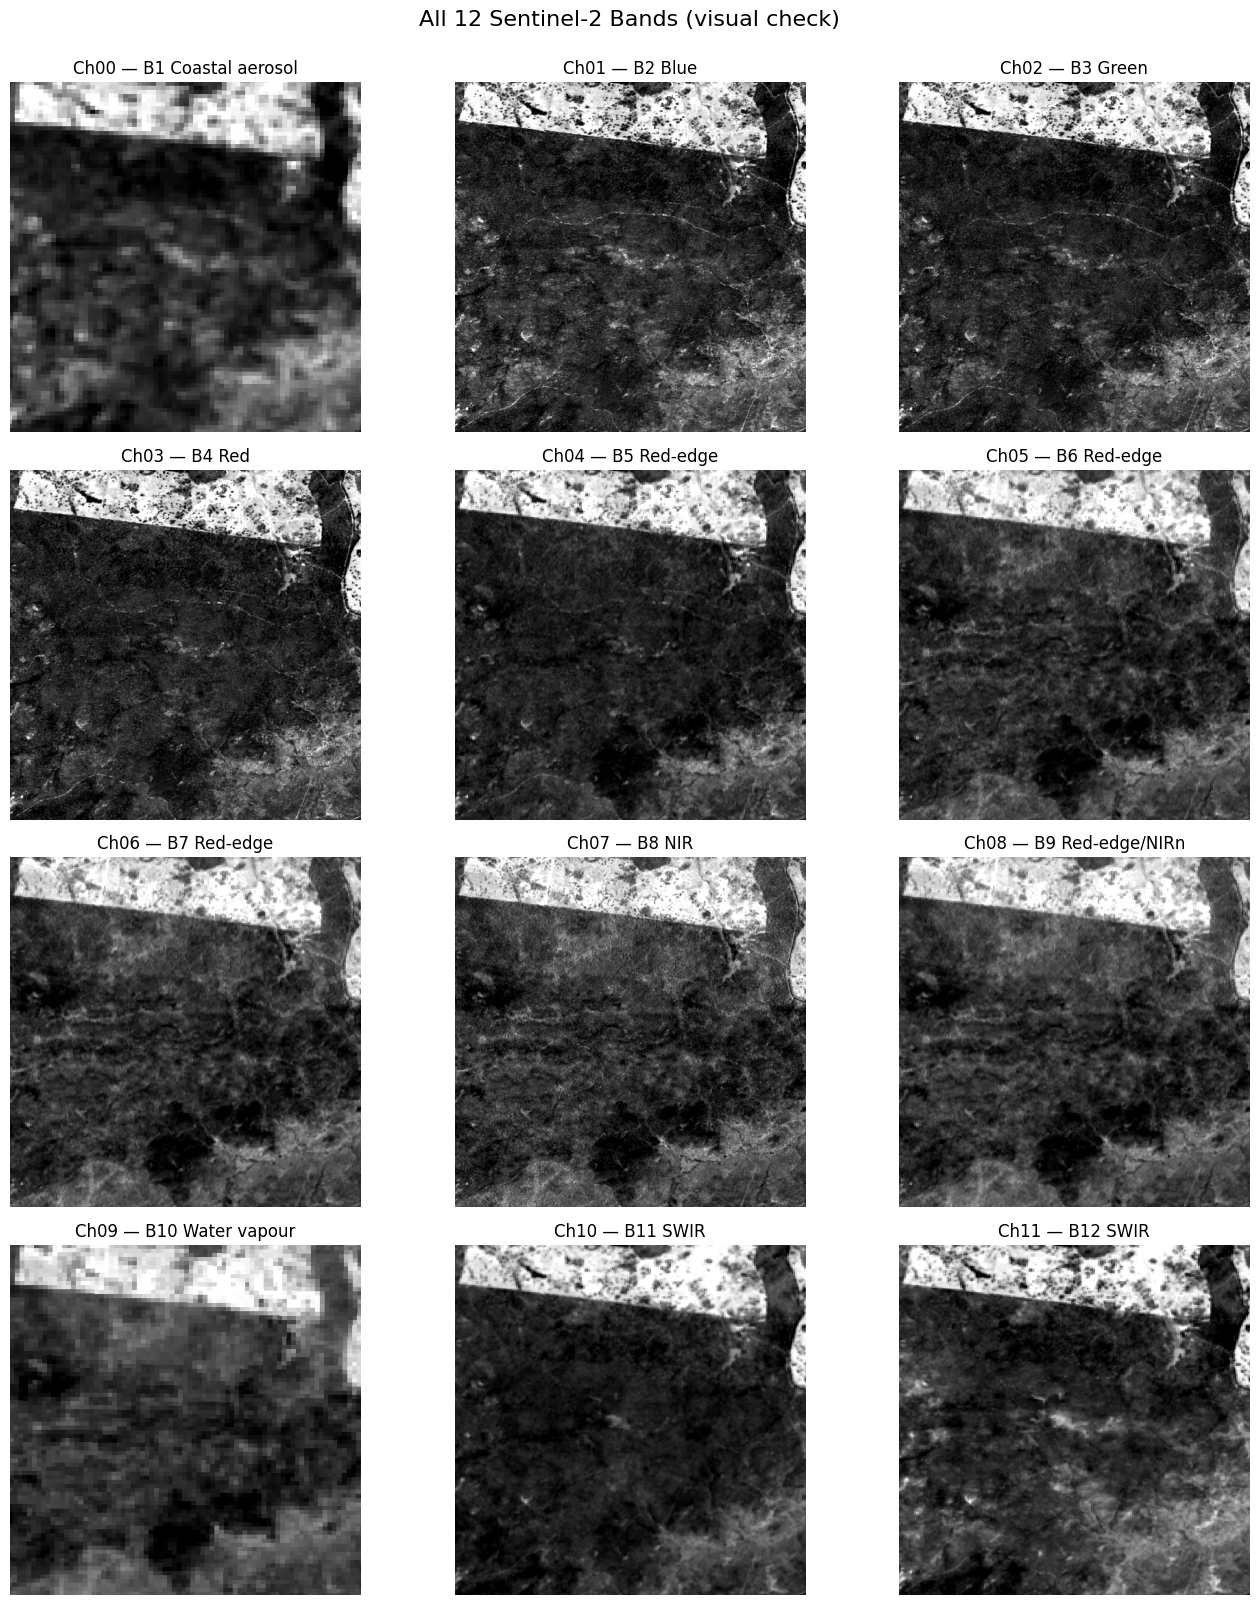

In [12]:
# ============================================================
# CELL 3.2 — Show all 12 bands (4x3 grid)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Optional: mapping index -> band name (assuming channel order follows Table 1)
# NOTE: This assumes image channels are ordered as B1..B12.
band_names = [
    "B1 Coastal aerosol", "B2 Blue", "B3 Green", "B4 Red",
    "B5 Red-edge", "B6 Red-edge", "B7 Red-edge", "B8 NIR",
    "B9 Red-edge/NIRn", "B10 Water vapour", "B11 SWIR", "B12 SWIR"
]

def normalize_for_view(img2d, p_low=2, p_high=98):
    """Percentile stretch for visualization"""
    vmin, vmax = np.percentile(img2d, p_low), np.percentile(img2d, p_high)
    out = (img2d - vmin) / (vmax - vmin + 1e-6)
    return np.clip(out, 0, 1)

def show_all_bands_4x3(x_hwc, title="All 12 Sentinel-2 Bands (visual check)"):
    assert x_hwc.ndim == 3, "Expected HWC"
    H, W, C = x_hwc.shape
    assert C == 12, f"Expected 12 channels, got {C}"

    fig, axes = plt.subplots(4, 3, figsize=(14, 16))
    axes = axes.ravel()

    for i in range(12):
        band = x_hwc[..., i].astype(np.float32)
        band_viz = normalize_for_view(band)

        axes[i].imshow(band_viz, cmap="gray")
        axes[i].set_title(f"Ch{i:02d} — {band_names[i]}")
        axes[i].axis("off")

    plt.suptitle(title, y=1, fontsize=16)
    plt.tight_layout()
    plt.show()

# Run for the same sample
x, y, a, meta = load_patch(sample_path)
print("Loaded:", sample_path)
print("Image HWC shape:", x.shape, "| dtype:", x.dtype)
show_all_bands_4x3(x)

In [10]:
# ============================================================
# CELL 3.5 — Band Statistics + Quality Flags
# ============================================================

import numpy as np
import pandas as pd

def band_stats(x_hwc):
    """
    Compute per-channel stats to detect weird channels:
    - min/max/mean/std
    - %zeros
    - unique ratio (rough indicator)
    """
    H, W, C = x_hwc.shape
    rows = []

    for c in range(C):
        arr = x_hwc[..., c].astype(np.float32)
        rows.append({
            "channel": c,
            "band_name": band_names[c] if c < len(band_names) else f"Ch{c}",
            "min": float(np.min(arr)),
            "p01": float(np.percentile(arr, 1)),
            "mean": float(np.mean(arr)),
            "p99": float(np.percentile(arr, 99)),
            "max": float(np.max(arr)),
            "std": float(np.std(arr)),
            "pct_zeros": float((arr == 0).mean() * 100.0),
        })

    return pd.DataFrame(rows)

def label_stats(y):
    if y is None:
        return {"label_exists": False}
    y_bin = (y > 0).astype(np.uint8)
    return {
        "label_exists": True,
        "shape": y.shape,
        "fire_pixels": int(y_bin.sum()),
        "total_pixels": int(y_bin.size),
        "fire_ratio": float(y_bin.mean()),
        "unique_values": np.unique(y).tolist()[:20],
    }

# Compute stats
x, y, a, meta = load_patch(sample_path)
df_stats = band_stats(x)
display(df_stats)

# Quality flags (heuristic)
# You can tune thresholds, these are conservative:
dead_std_thresh = 1e-3      # almost constant band
high_zero_thresh = 95.0     # mostly zero (suspicious)
df_stats["flag_dead_constant"] = df_stats["std"] < dead_std_thresh
df_stats["flag_mostly_zero"] = df_stats["pct_zeros"] > high_zero_thresh

display(df_stats[["channel","band_name","std","pct_zeros","flag_dead_constant","flag_mostly_zero"]])

# Label stats
ls = label_stats(y)
print("Label stats:", ls)

# Aerosol stats (optional)
if a is not None:
    a_f = a.astype(np.float32)
    print("Aerosol stats:",
          {"min": float(a_f.min()),
           "mean": float(a_f.mean()),
           "max": float(a_f.max()),
           "std": float(a_f.std())})
else:
    print("No aerosol layer found.")

,channel,band_name,min,p01,mean,p99,max,std,pct_zeros
0,0,B1 Coastal aerosol,119.0,216.0,364.498077,726.0,851.0,123.178062,0.0
1,1,B2 Blue,131.0,249.0,467.900391,1026.0,3482.0,182.433762,0.0
2,2,B3 Green,199.0,340.0,592.854492,1320.0,3022.0,236.838058,0.0
3,3,B4 Red,252.0,450.0,771.082153,1712.0,3034.0,293.252197,0.0
4,4,B5 Red-edge,509.0,654.0,992.729126,2033.0,2780.0,328.273254,0.0
5,5,B6 Red-edge,618.0,849.0,1359.959961,2659.0,3217.0,411.867065,0.0
6,6,B7 Red-edge,698.0,957.0,1543.170166,2962.0,3614.0,452.963501,0.0
7,7,B8 NIR,716.0,1028.0,1706.186035,3278.0,4060.0,504.998169,0.0
8,8,B9 Red-edge/NIRn,848.0,1109.0,1800.702881,3361.0,4001.0,508.140381,0.0
9,9,B10 Water vapour,930.0,1159.0,1814.235352,3297.0,3642.0,498.023560,0.0


,channel,band_name,std,pct_zeros,flag_dead_constant,flag_mostly_zero
0,0,B1 Coastal aerosol,123.178062,0.0,False,False
1,1,B2 Blue,182.433762,0.0,False,False
2,2,B3 Green,236.838058,0.0,False,False
3,3,B4 Red,293.252197,0.0,False,False
4,4,B5 Red-edge,328.273254,0.0,False,False
5,5,B6 Red-edge,411.867065,0.0,False,False
6,6,B7 Red-edge,452.963501,0.0,False,False
7,7,B8 NIR,504.998169,0.0,False,False
8,8,B9 Red-edge/NIRn,508.140381,0.0,False,False
9,9,B10 Water vapour,498.023560,0.0,False,False


Label stats: {'label_exists': True, 'shape': (512, 512), 'fire_pixels': 0, 'total_pixels': 262144, 'fire_ratio': 0.0, 'unique_values': [0]}
Aerosol stats: {'min': -1.4058924913406372, 'mean': -1.2380163669586182, 'max': -1.1978706121444702, 'std': 0.03729806840419769}


Berdasarkan table diatas, tidak ada channel yang rusak, bisa dilihat bahwa

`flag_dead_constant` >= 0.003, Band tidak memiliki nilai pixel yang konstan Bisa dilihat juga dari standar deviasi yang jauh dari 0, berarti pixel memiliki nilai beragam

`flag_mostly_zero` <= 95, Band tidak memiliki nilai pixel mayoritas nol

Dari **Label Stats** menunjukkan bahwa patch ini tidak mengandung piksel kebakaran (`fire_pixels = 0`), yang merupakan kondisi wajar mengingat distribusi kelas pada dataset kebakaran hutan bersifat sangat tidak seimbang. Dengan demikian, hasil ini tidak mengindikasikan kesalahan data, melainkan merepresentasikan karakteristik alami dataset wildfire.

Train stats (sampled):
  n: 200
  patch_with_fire: 40
  patch_without_fire: 160
  pct_patch_with_fire: 20.0
  mean_fire_ratio: 0.03853130340576172
  median_fire_ratio: 0.0
  max_fire_ratio: 0.6372146606445312
  min_fire_ratio: 0.0


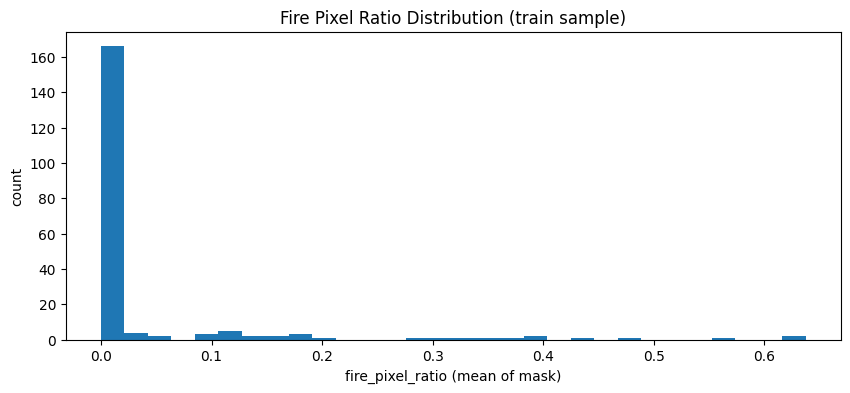

Showing example NO-FIRE patches...


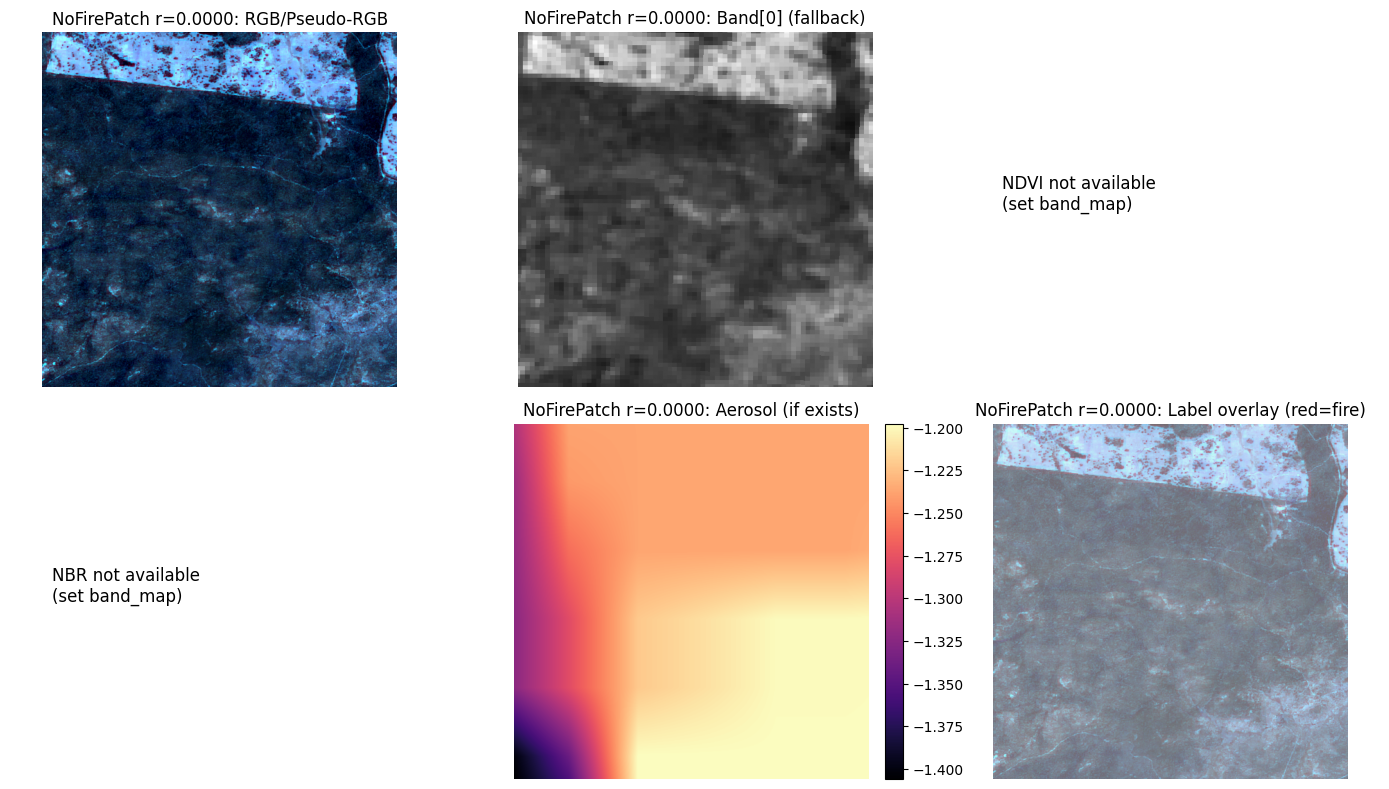

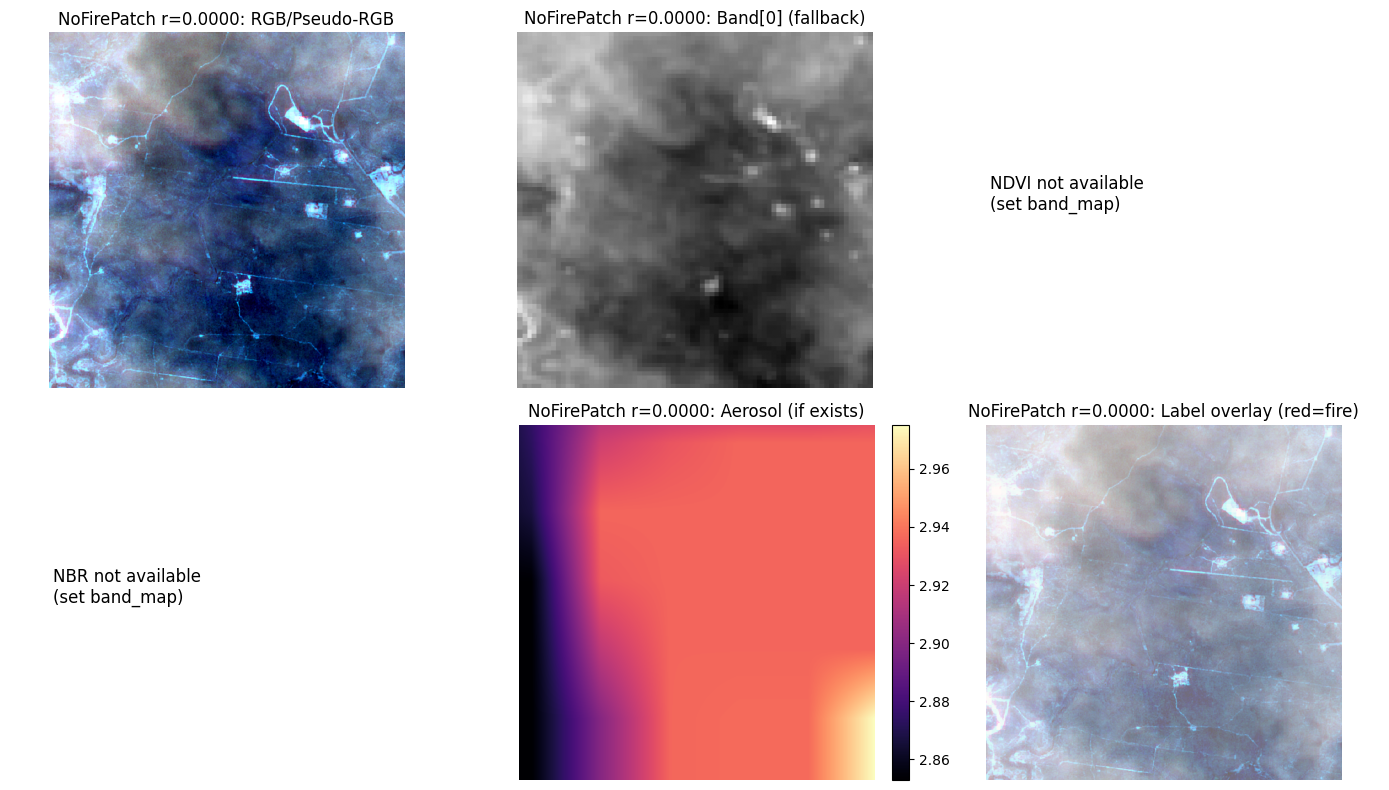

Showing example FIRE patches...


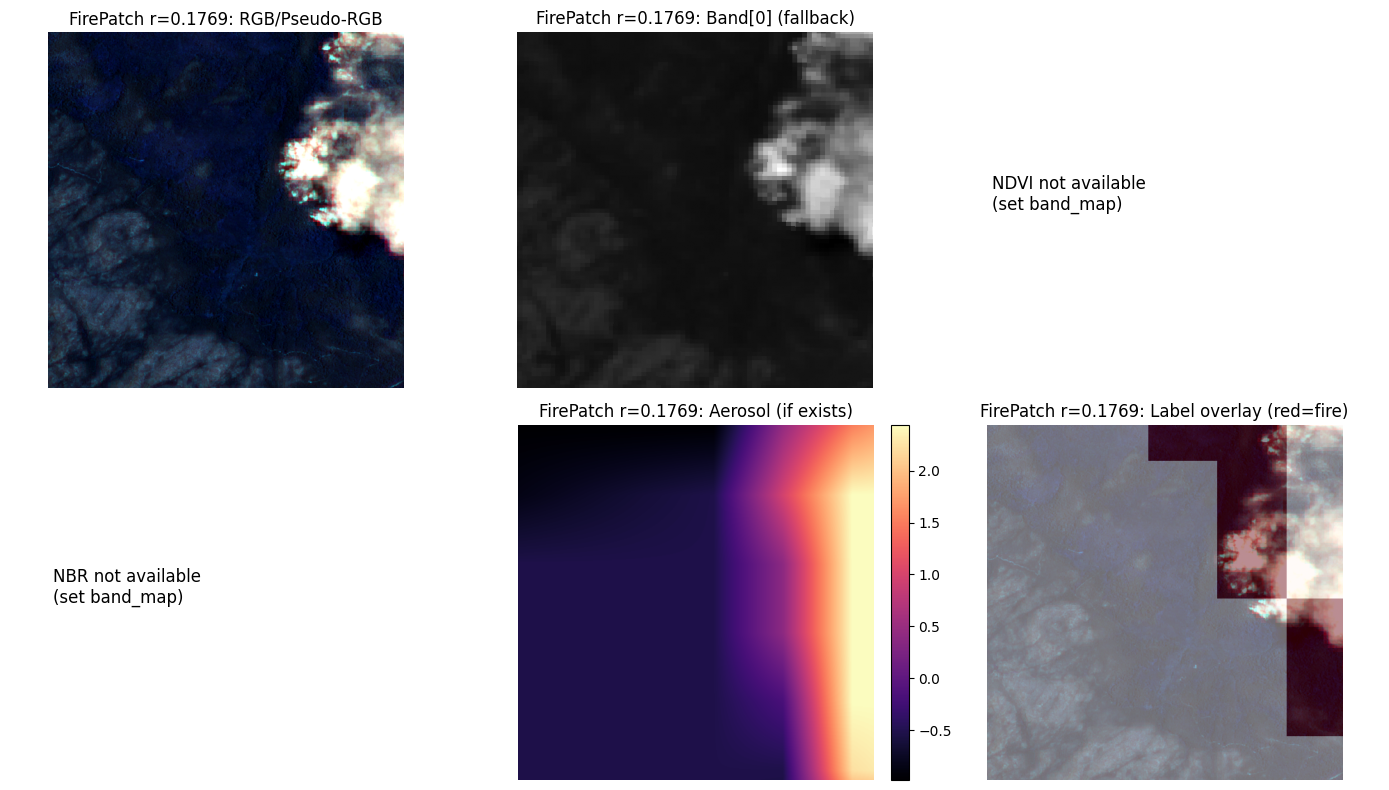

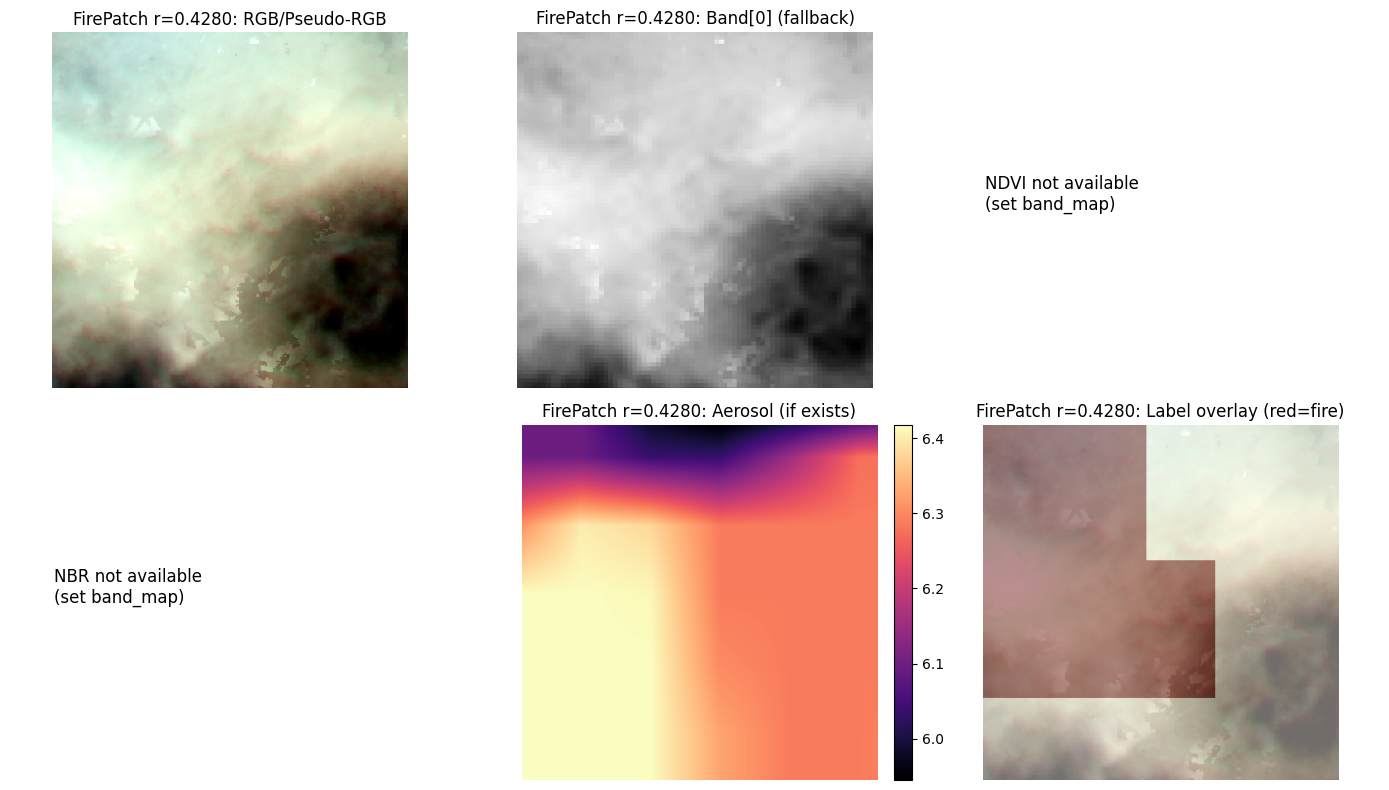

In [11]:
# ============================================================
# CELL 4 — Class Distribution + Fire Pixel Ratio Analysis
# Goal: avoid trivial model that predicts all non-fire
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_fire_ratio(y: np.ndarray) -> float:
    """y is (H,W) binary mask"""
    if y is None:
        return np.nan
    y_bin = (y > 0).astype(np.uint8)
    return float(y_bin.mean())

def scan_fire_stats(paths, max_items=None):
    ratios = []
    has_fire = []
    inspected = 0

    for i, p in enumerate(paths):
        if max_items is not None and inspected >= max_items:
            break
        x, y, a, meta = load_patch(p)
        r = compute_fire_ratio(y)
        ratios.append(r)
        has_fire.append(1 if (r > 0) else 0)
        inspected += 1

    ratios = np.array(ratios, dtype=np.float32)
    has_fire = np.array(has_fire, dtype=np.int32)

    stats = {
        "n": int(inspected),
        "patch_with_fire": int(has_fire.sum()),
        "patch_without_fire": int((1-has_fire).sum()),
        "pct_patch_with_fire": float(has_fire.mean() * 100.0),
        "mean_fire_ratio": float(np.nanmean(ratios)),
        "median_fire_ratio": float(np.nanmedian(ratios)),
        "max_fire_ratio": float(np.nanmax(ratios)),
        "min_fire_ratio": float(np.nanmin(ratios)),
    }
    return ratios, stats

# Scan small sample first (fast)
MAX_SCAN = min(300, len(train_paths))  # adjust as needed
train_ratios, train_stats = scan_fire_stats(train_paths, max_items=MAX_SCAN)

print("Train stats (sampled):")
for k, v in train_stats.items():
    print(f"  {k}: {v}")

# Plot histogram of fire ratios
plt.figure(figsize=(10,4))
plt.hist(train_ratios[~np.isnan(train_ratios)], bins=30)
plt.title("Fire Pixel Ratio Distribution (train sample)")
plt.xlabel("fire_pixel_ratio (mean of mask)")
plt.ylabel("count")
plt.show()

# Show a few examples: no-fire vs fire patches
def show_examples_by_fire(paths, want_fire=True, k=3):
    shown = 0
    for p in paths:
        x, y, a, meta = load_patch(p)
        r = compute_fire_ratio(y)
        if want_fire and r > 0:
            show_patch_views(x, y=y, a=a, band_map={}, title_prefix=f"FirePatch r={r:.4f}: ")
            shown += 1
        if (not want_fire) and r == 0:
            show_patch_views(x, y=y, a=a, band_map={}, title_prefix=f"NoFirePatch r={r:.4f}: ")
            shown += 1
        if shown >= k:
            break

print("Showing example NO-FIRE patches...")
show_examples_by_fire(train_paths, want_fire=False, k=2)

print("Showing example FIRE patches...")
show_examples_by_fire(train_paths, want_fire=True, k=2)

In [13]:
# ============================================================
# CELL 5 — PyTorch Dataset (13 channels: 12 S2 + 1 Aerosol)
# ============================================================

import numpy as np
import torch
from torch.utils.data import Dataset

class Sen2FireSegDataset(Dataset):
    """
    Loads one .npz patch containing:
      - image: (12,H,W) or (H,W,12)  int16
      - aerosol: (H,W)               float-ish
      - label: (H,W)                 0/1 (or 0..255 but effectively binary)
    Returns:
      X: torch.float32 (13,H,W)
      y: torch.float32 (1,H,W)
    """

    def __init__(self, paths, img_key="image", aer_key="aerosol", label_key="label",
                 normalize=True, mean=None, std=None, band_map=None, debug=False):
        self.paths = list(paths)
        self.img_key = img_key
        self.aer_key = aer_key
        self.label_key = label_key

        self.normalize = normalize
        self.mean = mean
        self.std = std
        self.debug = debug

        # Optional mapping for computing NDVI/NBR later (not used in this cell)
        self.band_map = band_map or {
            "B1":0, "B2":1, "B3":2, "B4":3, "B5":4, "B6":5, "B7":6,
            "B8":7, "B9":8, "B10":9, "B11":10, "B12":11
        }

        if self.normalize:
            if (self.mean is None) or (self.std is None):
                raise ValueError("normalize=True requires mean and std (per-channel).")

            self.mean = np.asarray(self.mean, dtype=np.float32)
            self.std = np.asarray(self.std, dtype=np.float32)

            if self.mean.shape[0] != 13 or self.std.shape[0] != 13:
                raise ValueError(f"mean/std must be length 13 (12 S2 + 1 aerosol). Got mean={self.mean.shape}, std={self.std.shape}")

    def __len__(self):
        return len(self.paths)

    def _load_npz(self, path):
        with np.load(path) as data:
            if self.img_key not in data:
                raise KeyError(f"'{self.img_key}' not found in {path}. keys={list(data.keys())}")
            if self.aer_key not in data:
                raise KeyError(f"'{self.aer_key}' not found in {path}. keys={list(data.keys())}")
            if self.label_key not in data:
                raise KeyError(f"'{self.label_key}' not found in {path}. keys={list(data.keys())}")

            x = data[self.img_key]       # (12,H,W) or (H,W,12)
            a = data[self.aer_key]       # (H,W)
            y = data[self.label_key]     # (H,W) or (H,W,1)
        return x, a, y

    def _to_hwc(self, x):
        # normalize shape to (H,W,C)
        if x.ndim != 3:
            raise ValueError(f"Expected 3D image array, got shape={x.shape}")

        # if CHW: (12,H,W)
        if x.shape[0] == 12 and x.shape[-1] != 12:
            x = np.transpose(x, (1, 2, 0))
        # else assume HWC already
        return x

    def __getitem__(self, idx):
        path = self.paths[idx]
        x, a, y = self._load_npz(path)

        x = self._to_hwc(x).astype(np.float32)  # (H,W,12)
        a = a.astype(np.float32)                # (H,W)
        if y.ndim == 3 and y.shape[-1] == 1:
            y = y[..., 0]
        y = (y > 0).astype(np.float32)          # (H,W) binary

        # Stack aerosol as channel-13
        a = a[..., None]                        # (H,W,1)
        x13 = np.concatenate([x, a], axis=-1)   # (H,W,13)

        # HWC -> CHW for PyTorch
        x13 = np.transpose(x13, (2, 0, 1))      # (13,H,W)
        y = y[None, ...]                        # (1,H,W)

        # Normalize per channel if enabled
        if self.normalize:
            # (13,H,W) - (13,1,1)
            x13 = (x13 - self.mean[:, None, None]) / (self.std[:, None, None] + 1e-6)

        X = torch.from_numpy(x13).float()
        Y = torch.from_numpy(y).float()

        if self.debug:
            return X, Y, path
        return X, Y

# 3. Normalize band

In [14]:
# ============================================================
# CELL 6 — Compute Mean/Std for 13 channels (12 S2 + aerosol)
# ============================================================

import numpy as np

def compute_mean_std_13(paths, max_items=200, img_key="image", aer_key="aerosol", label_key="label"):
    """
    Compute per-channel mean/std for X (13 channels) using up to max_items patches.
    Uses streaming accumulation to be memory safe.
    Returns:
      mean: (13,)
      std : (13,)
    """

    n_used = 0
    sum_c = np.zeros((13,), dtype=np.float64)
    sumsq_c = np.zeros((13,), dtype=np.float64)
    count_per_c = 0

    for i, p in enumerate(paths):
        if n_used >= max_items:
            break

        with np.load(p) as data:
            x = data[img_key]
            a = data[aer_key]

        # Ensure HWC for image
        if x.ndim != 3:
            raise ValueError(f"Expected 3D image, got {x.shape} in {p}")
        if x.shape[0] == 12 and x.shape[-1] != 12:
            x = np.transpose(x, (1, 2, 0))  # CHW->HWC
        x = x.astype(np.float32)  # (H,W,12)

        a = a.astype(np.float32)  # (H,W)
        a = a[..., None]          # (H,W,1)

        x13 = np.concatenate([x, a], axis=-1)  # (H,W,13)

        # Flatten spatial dims
        H, W, C = x13.shape
        flat = x13.reshape(-1, C)  # (H*W, 13)

        sum_c += flat.sum(axis=0)
        sumsq_c += (flat ** 2).sum(axis=0)
        count_per_c += flat.shape[0]
        n_used += 1

    mean = sum_c / (count_per_c + 1e-12)
    var = (sumsq_c / (count_per_c + 1e-12)) - (mean ** 2)
    var = np.maximum(var, 1e-12)
    std = np.sqrt(var)

    return mean.astype(np.float32), std.astype(np.float32), n_used

# Compute using your train_paths (already small-sampled and balanced at patch-level)
MEAN_13, STD_13, N_USED = compute_mean_std_13(train_paths, max_items=min(200, len(train_paths)))
print("Computed normalization stats from patches:", N_USED)
print("MEAN_13 shape:", MEAN_13.shape, "STD_13 shape:", STD_13.shape)

# Optional: print summary per channel
channel_names_13 = [
    "B1","B2","B3","B4","B5","B6","B7","B8","B9","B10","B11","B12","Aerosol"
]
for i, name in enumerate(channel_names_13):
    print(f"{i:02d} {name:>7s} | mean={MEAN_13[i]:.4f} | std={STD_13[i]:.4f}")

# Create datasets (train/val/test)
train_ds = Sen2FireSegDataset(train_paths, normalize=True, mean=MEAN_13, std=STD_13)
val_ds   = Sen2FireSegDataset(val_paths,   normalize=True, mean=MEAN_13, std=STD_13)
test_ds  = Sen2FireSegDataset(test_paths,  normalize=True, mean=MEAN_13, std=STD_13)

print("Dataset sizes:", len(train_ds), len(val_ds), len(test_ds))

# Quick shape check
X0, Y0 = train_ds[0]
print("One sample shapes => X:", tuple(X0.shape), "Y:", tuple(Y0.shape), "| dtype:", X0.dtype, Y0.dtype)

Computed normalization stats from patches: 200
MEAN_13 shape: (13,) STD_13 shape: (13,)
00      B1 | mean=668.7072 | std=568.2781
01      B2 | mean=709.6716 | std=553.7458
02      B3 | mean=791.4719 | std=482.8889
03      B4 | mean=864.7316 | std=471.9166
04      B5 | mean=1126.4850 | std=435.2961
05      B6 | mean=1576.6495 | std=407.9568
06      B7 | mean=1786.2474 | std=443.9681
07      B8 | mean=1954.2817 | std=492.3847
08      B9 | mean=2036.4316 | std=480.8414
09     B10 | mean=2036.2124 | std=473.6641
10     B11 | mean=2316.8953 | std=1012.6206
11     B12 | mean=1629.1743 | std=937.4705
12 Aerosol | mean=0.4120 | std=2.0510
Dataset sizes: 200 60 60
One sample shapes => X: (13, 512, 512) Y: (1, 512, 512) | dtype: torch.float32 torch.float32


# 4. Imbalanced handling

In [15]:
# ============================================================
# CELL 7 — DataLoader + WeightedRandomSampler + Batch Sanity
# Goal:
# 1) Ensure batches contain enough fire patches (patch-level imbalance handling)
# 2) Verify tensor shapes, ranges, and label presence
# ============================================================

import torch
from torch.utils.data import DataLoader, WeightedRandomSampler

# ----------------------------
# 1) Build per-sample weights for train sampling
#    Weight fire-patches higher so they appear more often in batches.
# ----------------------------

def has_fire_fast(npz_path: str, label_key="label") -> int:
    with np.load(npz_path) as data:
        y = data[label_key]
        if y.ndim == 3 and y.shape[-1] == 1:
            y = y[..., 0]
        return int((y > 0).any())

train_has_fire = [has_fire_fast(p, label_key="label") for p in train_paths]

n_pos = sum(train_has_fire)
n_neg = len(train_has_fire) - n_pos
print("Train patches:", len(train_has_fire), "| has_fire=1:", n_pos, "| has_fire=0:", n_neg)

# Weights: inverse frequency (common strategy)
# If positives are rare, each positive gets larger weight.
w_pos = 1.0 / max(n_pos, 1)
w_neg = 1.0 / max(n_neg, 1)

sample_weights = [w_pos if hf == 1 else w_neg for hf in train_has_fire]
sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),  # one "epoch" length
    replacement=True
)

# ----------------------------
# 2) DataLoaders
# ----------------------------
BATCH_SIZE = 4
NUM_WORKERS = 2  # set 0 if Windows/local issues

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# ----------------------------
# 3) Batch sanity check
# ----------------------------
def batch_sanity_check(loader, n_batches=2):
    for bi, (X, Y) in enumerate(loader):
        print(f"\nBatch {bi} => X: {tuple(X.shape)} | Y: {tuple(Y.shape)} | dtype: {X.dtype}")
        # X should be (B, 13, 512, 512), Y should be (B, 1, 512, 512)
        print("X min/max:", float(X.min()), float(X.max()))
        print("Y unique:", torch.unique(Y))
        # How many samples in this batch contain any fire pixels?
        batch_has_fire = (Y.sum(dim=(1,2,3)) > 0).sum().item()
        print("Batch samples with fire:", batch_has_fire, "/", X.shape[0])

        if bi + 1 >= n_batches:
            break

batch_sanity_check(train_loader, n_batches=2)

Train patches: 200 | has_fire=1: 40 | has_fire=0: 160


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Batch 0 => X: (4, 13, 512, 512) | Y: (4, 1, 512, 512) | dtype: torch.float32
X min/max: -3.6034462451934814 13.302633285522461
Y unique: tensor([0., 1.])
Batch samples with fire: 2 / 4

Batch 1 => X: (4, 13, 512, 512) | Y: (4, 1, 512, 512) | dtype: torch.float32
X min/max: -3.7526543140411377 8.317706108093262
Y unique: tensor([0.])
Batch samples with fire: 0 / 4


# 5. Baseline Model (U-Net)

In [16]:
# ============================================================
# CELL 8 — Model + Loss + Metrics
# Goal:
# - Use a simple, stable baseline U-Net for 13-channel segmentation
# - Handle pixel-level imbalance via BCEWithLogits + Soft Dice
# - Provide metrics: precision/recall/F1/IoU for fire class
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

# ----------------------------
# 1) Simple U-Net (lightweight baseline)
# ----------------------------
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class UNetSmall(nn.Module):
    def __init__(self, in_channels=13, out_channels=1, base=32):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, base)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(base, base*2)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = DoubleConv(base*2, base*4)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base*4, base*8)

        self.up3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.dec3 = DoubleConv(base*8, base*4)
        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.dec2 = DoubleConv(base*4, base*2)
        self.up1 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.dec1 = DoubleConv(base*2, base)

        self.out = nn.Conv2d(base, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        logits = self.out(d1)
        return logits

model = UNetSmall(in_channels=13, out_channels=1, base=32).to(DEVICE)
print(model.__class__.__name__, "ready on", DEVICE)

# ----------------------------
# 2) Loss: BCEWithLogits + Soft Dice
# ----------------------------
def soft_dice_loss(logits, targets, eps=1e-6):
    """
    logits: (B,1,H,W)
    targets: (B,1,H,W) in {0,1}
    """
    probs = torch.sigmoid(logits)
    num = 2.0 * (probs * targets).sum(dim=(2,3))
    den = (probs + targets).sum(dim=(2,3)) + eps
    dice = num / den
    return 1.0 - dice.mean()

# pos_weight for BCE helps pixel imbalance:
# approximate from one batch or from dataset later; start simple with pos_weight=5~20
POS_WEIGHT = 10.0
bce_loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([POS_WEIGHT], device=DEVICE))

def combined_loss(logits, targets, alpha=0.5):
    """
    alpha: weight between BCE and Dice
    """
    bce = bce_loss_fn(logits, targets)
    dice = soft_dice_loss(logits, targets)
    return alpha*bce + (1-alpha)*dice, bce.detach(), dice.detach()

# ----------------------------
# 3) Metrics: Precision/Recall/F1/IoU for fire class
# ----------------------------
@torch.no_grad()
def compute_metrics_from_logits(logits, targets, thr=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs >= thr).float()

    tp = (preds * targets).sum(dim=(1,2,3))
    fp = (preds * (1 - targets)).sum(dim=(1,2,3))
    fn = ((1 - preds) * targets).sum(dim=(1,2,3))

    precision = (tp / (tp + fp + eps)).mean().item()
    recall    = (tp / (tp + fn + eps)).mean().item()
    f1        = (2*tp / (2*tp + fp + fn + eps)).mean().item()

    # IoU = TP / (TP + FP + FN)
    iou = (tp / (tp + fp + fn + eps)).mean().item()

    return {"precision": precision, "recall": recall, "f1": f1, "iou": iou}

UNetSmall ready on cpu


# 6. Overfit Sanity Check

In [21]:
# ============================================================
# FIX — Overfit Sanity Check must use a FIXED BATCH with fire pixels
# Strategy:
# 1) Build a small dataset of ONLY fire patches (has_fire=1)
# 2) Take one fixed batch from it (guaranteed Y has positives)
# 3) Repeat training on that batch
# ============================================================

import numpy as np
import torch
from torch.utils.data import Subset, DataLoader

# 1) Collect indices that truly have fire pixels (has_fire=1)
fire_indices = [i for i, hf in enumerate(train_has_fire) if hf == 1]
print("Total fire patches available:", len(fire_indices))

if len(fire_indices) < 2:
    raise RuntimeError("Not enough fire patches to run fire-only overfit sanity. Increase training sample or rescan train_has_fire.")

# 2) Build fire-only subset (take e.g. first 16 fire patches)
k_fire_only = min(16, len(fire_indices))
fire_only_subset = Subset(train_ds, fire_indices[:k_fire_only])

fire_only_loader = DataLoader(fire_only_subset, batch_size=2, shuffle=True, num_workers=0)

# 3) Grab one FIXED batch that is guaranteed to contain fire pixels
X_fix, Y_fix = next(iter(fire_only_loader))
X_fix, Y_fix = X_fix.to(DEVICE), Y_fix.to(DEVICE)

print("Fixed fire batch shapes:", tuple(X_fix.shape), tuple(Y_fix.shape))
print("Fixed fire batch total fire pixels:", float(Y_fix.sum().item()))
print("Fixed fire batch samples with fire:", int((Y_fix.sum(dim=(1,2,3)) > 0).sum().item()), "/", X_fix.shape[0])

if Y_fix.sum().item() == 0:
    raise RuntimeError("Unexpected: picked a fire-only batch but got zero fire pixels. Check label loading/binarization.")

# 4) More stable loss for sanity check: reduce POS_WEIGHT
POS_WEIGHT = 3.0
bce_loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([POS_WEIGHT], device=DEVICE))

def soft_dice_loss(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    num = 2.0 * (probs * targets).sum(dim=(2,3))
    den = (probs + targets).sum(dim=(2,3)) + eps
    dice = num / den
    return 1.0 - dice.mean()

def combined_loss_local(logits, targets, alpha=0.5):
    bce = bce_loss_fn(logits, targets)
    dice = soft_dice_loss(logits, targets)
    return alpha*bce + (1-alpha)*dice, bce.detach(), dice.detach()

@torch.no_grad()
def eval_thresholds(logits, targets, thrs=(0.1,0.2,0.3,0.4,0.5)):
    print("Threshold sweep:")
    for t in thrs:
        mets = compute_metrics_from_logits(logits, targets, thr=t)
        print(f"  thr={t:.1f} -> F1={mets['f1']:.4f} IoU={mets['iou']:.4f} P={mets['precision']:.4f} R={mets['recall']:.4f}")

# 5) Fixed-batch overfit loop
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def run_fixed_fire_overfit(model, X, Y, steps=200, thr_main=0.5, alpha=0.5):
    model.train()
    for step in range(steps):
        optimizer.zero_grad()
        logits = model(X)
        loss, bce_part, dice_part = combined_loss_local(logits, Y, alpha=alpha)
        loss.backward()
        optimizer.step()

        if step % 20 == 0:
            mets = compute_metrics_from_logits(logits.detach(), Y, thr=thr_main)
            probs = torch.sigmoid(logits.detach())
            pred_pos = float((probs >= thr_main).float().sum().item())
            true_pos = float(Y.sum().item())

            print(f"\nStep {step:03d}")
            print(f"  loss={loss.item():.4f} | bce={bce_part.item():.4f} | dice_loss={dice_part.item():.4f}")
            print(f"  @thr={thr_main:.2f} -> F1={mets['f1']:.4f} IoU={mets['iou']:.4f} P={mets['precision']:.4f} R={mets['recall']:.4f}")
            print(f"  pred_pos_pixels={pred_pos:.0f} | true_pos_pixels={true_pos:.0f}")

            eval_thresholds(logits.detach(), Y, thrs=(0.1,0.2,0.3,0.4,0.5))

run_fixed_fire_overfit(model, X_fix, Y_fix, steps=150, thr_main=0.5, alpha=0.5)

Total fire patches available: 40
Fixed fire batch shapes: (2, 13, 512, 512) (2, 1, 512, 512)
Fixed fire batch total fire pixels: 201902.0
Fixed fire batch samples with fire: 2 / 2

Step 000
  loss=1.7098 | bce=2.6140 | dice_loss=0.8056
  @thr=0.50 -> F1=0.0000 IoU=0.0000 P=0.0000 R=0.0000
  pred_pos_pixels=0 | true_pos_pixels=201902
Threshold sweep:
  thr=0.1 -> F1=0.4736 IoU=0.3430 P=0.3801 R=0.8967
  thr=0.2 -> F1=0.2110 IoU=0.1184 P=0.5791 R=0.1294
  thr=0.3 -> F1=0.0419 IoU=0.0217 P=0.6787 R=0.0223
  thr=0.4 -> F1=0.0034 IoU=0.0017 P=0.7411 R=0.0017
  thr=0.5 -> F1=0.0000 IoU=0.0000 P=0.0000 R=0.0000

Step 020
  loss=0.6143 | bce=0.7884 | dice_loss=0.4402
  @thr=0.50 -> F1=0.6780 IoU=0.5213 P=0.5705 R=0.8389
  pred_pos_pixels=309762 | true_pos_pixels=201902
Threshold sweep:
  thr=0.1 -> F1=0.6204 IoU=0.4684 P=0.4689 R=0.9954
  thr=0.2 -> F1=0.6472 IoU=0.4920 P=0.4933 R=0.9896
  thr=0.3 -> F1=0.6766 IoU=0.5199 P=0.5251 R=0.9711
  thr=0.4 -> F1=0.6877 IoU=0.5310 P=0.5497 R=0.9207
  t

# 7. Training model

In [ ]:
# ============================================================
# CELL 10 — Baseline Training Loop (small sample)
# Goal:
# - Train with sampler (patch-level imbalance)
# - Evaluate on val (natural distribution)
# - Save best model by val F1
# ============================================================

import os
from tqdm import tqdm

EPOCHS = 5
LR = 1e-3
THR = 0.5

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0
    total_bce = 0.0
    total_dice = 0.0

    for X, Y in tqdm(loader, desc="train", leave=False):
        X = X.to(DEVICE)
        Y = Y.to(DEVICE)

        optimizer.zero_grad()
        logits = model(X)
        loss, bce_part, dice_part = combined_loss(logits, Y, alpha=0.5)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_bce += bce_part.item()
        total_dice += dice_part.item()

    n = len(loader)
    return {
        "loss": total_loss / n,
        "bce": total_bce / n,
        "dice": total_dice / n
    }

@torch.no_grad()
def evaluate(model, loader, thr=0.5):
    model.eval()
    # aggregate metrics
    precisions, recalls, f1s, ious = [], [], [], []

    for X, Y in tqdm(loader, desc="eval", leave=False):
        X = X.to(DEVICE)
        Y = Y.to(DEVICE)
        logits = model(X)
        mets = compute_metrics_from_logits(logits, Y, thr=thr)
        precisions.append(mets["precision"])
        recalls.append(mets["recall"])
        f1s.append(mets["f1"])
        ious.append(mets["iou"])

    return {
        "precision": float(np.mean(precisions)),
        "recall": float(np.mean(recalls)),
        "f1": float(np.mean(f1s)),
        "iou": float(np.mean(ious)),
    }

best_f1 = -1.0
CKPT_DIR = "./checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)
best_path = os.path.join(CKPT_DIR, "unet13_best.pth")

history = []

for epoch in range(1, EPOCHS+1):
    tr = train_one_epoch(model, train_loader)
    va = evaluate(model, val_loader, thr=THR)

    row = {"epoch": epoch, **tr, **va}
    history.append(row)

    print(f"\nEpoch {epoch}/{EPOCHS}")
    print(f"  Train: loss={tr['loss']:.4f} | bce={tr['bce']:.4f} | dice={tr['dice']:.4f}")
    print(f"  Val  : precision={va['precision']:.4f} | recall={va['recall']:.4f} | F1={va['f1']:.4f} | IoU={va['iou']:.4f}")

    # Save best
    if va["f1"] > best_f1:
        best_f1 = va["f1"]
        torch.save({
            "model_state": model.state_dict(),
            "mean_13": MEAN_13,
            "std_13": STD_13,
            "thr": THR,
            "pos_weight": POS_WEIGHT,
            "epoch": epoch,
            "val_f1": best_f1,
        }, best_path)
        print("  ✅ Saved best checkpoint:", best_path)

# Show training history as a DataFrame
history_df = pd.DataFrame(history)
display(history_df)

## Loading model (kalau ada file model yang pernah di train, berarti gaperlu start dari awal)

In [ ]:
ckpt = torch.load("./checkpoints/unet13_best.pth", map_location=DEVICE)

model.load_state_dict(ckpt["model_state"])
model.to(DEVICE)
model.eval()

# Ada 13 channel makanya dinamain mean_13, std_13
MEAN_13 = ckpt["mean_13"]
STD_13  = ckpt["std_13"]
THR     = ckpt["thr"]

# 8. Pengembangan 1: Risk Mapping

In [ ]:
# ============================================================
# CELL RM1 — Data-driven pixel threshold t_high
# Goal: choose t_high that best matches labels on validation (Dice)
# ============================================================

import numpy as np
import torch

@torch.no_grad()
def dice_from_prob(prob_map, y_true, thr=0.5, eps=1e-6):
    """
    prob_map: (H,W) float [0,1]
    y_true  : (H,W) float {0,1}
    """
    pred = (prob_map >= thr).astype(np.float32)
    y = (y_true > 0).astype(np.float32)

    tp = (pred * y).sum()
    fp = (pred * (1 - y)).sum()
    fn = ((1 - pred) * y).sum()
    dice = (2*tp) / (2*tp + fp + fn + eps)
    return float(dice)

@torch.no_grad()
def predict_prob_map_from_ds(model, ds, idx, device):
    X, Y = ds[idx]                 # X:(13,H,W) Y:(1,H,W)
    X = X.unsqueeze(0).to(device)  # (1,13,H,W)
    logits = model(X)              # (1,1,H,W)
    prob = torch.sigmoid(logits)[0,0].cpu().numpy().astype(np.float32)
    y = Y[0].cpu().numpy().astype(np.float32)
    return prob, y

def choose_best_t_high(model, val_ds, device, max_items=80, thr_candidates=None):
    if thr_candidates is None:
        thr_candidates = np.arange(0.20, 0.81, 0.05)  # 0.20..0.80 step 0.05

    n = min(max_items, len(val_ds))
    scores = []

    for thr in thr_candidates:
        dices = []
        for i in range(n):
            prob, y = predict_prob_map_from_ds(model, val_ds, i, device)
            dices.append(dice_from_prob(prob, y, thr=thr))
        scores.append((thr, float(np.mean(dices))))

    best_thr, best_score = max(scores, key=lambda x: x[1])
    return best_thr, best_score, scores

T_HIGH, BEST_DICE, all_scores = choose_best_t_high(model, val_ds, DEVICE, max_items=min(80, len(val_ds)))
print("Chosen t_high (data-driven):", T_HIGH, "| mean Dice on val subset:", BEST_DICE)

# Optional: print table
for thr, sc in all_scores:
    print(f"thr={thr:.2f} -> mean_dice={sc:.4f}")

Threshold p≥t untuk mendefinisikan area berisiko tidak dipilih manual, melainkan dioptimalkan menggunakan validation set dengan memaksimalkan Dice.

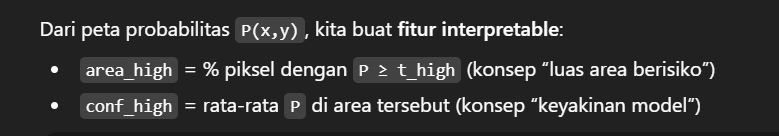

In [ ]:
# ============================================================
# CELL RM2 — Compute risk features per patch (area_high, conf_high)
# ============================================================

import numpy as np

def risk_features(prob_map, t_high):
    """
    Returns:
      area_high: fraction of pixels with prob>=t_high
      conf_high: mean prob among those pixels (0 if none)
    """
    mask = (prob_map >= t_high).astype(np.uint8)
    area_high = float(mask.mean())
    if mask.sum() > 0:
        conf_high = float(prob_map[mask == 1].mean())
    else:
        conf_high = 0.0
    return area_high, conf_high

@torch.no_grad()
def build_risk_table(model, ds, device, t_high, max_items=200):
    """
    Create a dataframe-like dict of features + target
    target = has_fire (from label): 1 if any fire pixel in GT else 0
    """
    n = min(max_items, len(ds))
    area_list, conf_list, ypatch_list = [], [], []

    for i in range(n):
        prob, y = predict_prob_map_from_ds(model, ds, i, device)
        area_high, conf_high = risk_features(prob, t_high=t_high)

        has_fire = int((y > 0).any())  # patch-level GT presence
        area_list.append(area_high)
        conf_list.append(conf_high)
        ypatch_list.append(has_fire)

    return np.array(area_list, np.float32), np.array(conf_list, np.float32), np.array(ypatch_list, np.int32)

val_area, val_conf, val_has_fire = build_risk_table(model, val_ds, DEVICE, t_high=T_HIGH, max_items=min(300, len(val_ds)))

print("Val patches used:", len(val_area))
print("Val has_fire ratio:", val_has_fire.mean())
print("Example features:", list(zip(val_area[:5], val_conf[:5], val_has_fire[:5])))

Kami menurunkan dua fitur risiko yang interpretable dari output model: **proporsi area berisiko (Area High-Risk)** dan **keyakinan model (Confidence Mean)** pada area tersebut.

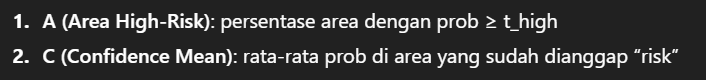

In [ ]:
# ============================================================
# CELL RM3 — Learn Fire Risk Index (FRI) from data (no hand weights)
# FRI = logistic_regression(area_high, conf_high) => probability [0,1]
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

X_val = np.stack([val_area, val_conf], axis=1)  # (N,2)
y_val = val_has_fire                             # (N,)

# Train logistic regression on validation-derived features
# (If you want stricter: train on train-features, validate on val-features.
#  For simplicity and to avoid leakage, we will later do a train/val split inside val set.)
lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(X_val, y_val)

fri_val = lr.predict_proba(X_val)[:, 1]  # FRI in [0,1]

print("Learned coefficients:")
print("  intercept:", lr.intercept_)
print("  coef(area_high, conf_high):", lr.coef_)

# Quick evaluation (patch-level)
pred_bin = (fri_val >= 0.5).astype(int)
print("Patch-level evaluation on val (quick):")
print("  AUC:", roc_auc_score(y_val, fri_val))
print("  Precision:", precision_score(y_val, pred_bin, zero_division=0))
print("  Recall   :", recall_score(y_val, pred_bin, zero_division=0))
print("  F1       :", f1_score(y_val, pred_bin, zero_division=0))

Kami tidak menetapkan bobot gabungan secara manual. Sebagai gantinya, kami melakukan calibration berbasis data menggunakan logistic regression untuk memetakan dua fitur risiko (area, confidence) menjadi probabilitas patch mengandung fire. Nilai probabilitas ini digunakan sebagai Fire Risk Index (FRI).

In [ ]:
# ============================================================
# CELL RM4 — Risk level thresholds (data-driven) + user-facing function
# ============================================================

import numpy as np

# Data-driven thresholds from FRI distribution
t_low  = float(np.quantile(fri_val, 0.50))  # median
t_high = float(np.quantile(fri_val, 0.85))  # top-risk band

print("Risk thresholds from val FRI distribution:")
print("  LOW    < ", t_low)
print("  MEDIUM <= ", t_high)
print("  HIGH   > ", t_high)

def risk_level(fri, t_low, t_high):
    if fri < t_low:
        return "LOW"
    elif fri <= t_high:
        return "MEDIUM"
    else:
        return "HIGH"

@torch.no_grad()
def predict_risk_for_patch(model, lr_model, npz_path, mean13, std13, device, t_pixel_high, t_low, t_high,
                           img_key="image", aer_key="aerosol", label_key="label"):
    """
    User-facing:
      - Load patch npz
      - Build 13-channel tensor (normalized)
      - Predict prob_map
      - Compute risk features (area_high, conf_high)
      - Compute FRI via logistic regression
      - Assign LOW/MEDIUM/HIGH
    Returns dict with everything needed for Streamlit
    """
    # Load raw
    with np.load(npz_path) as data:
        x = data[img_key]
        a = data[aer_key]

    # CHW -> HWC if needed
    if x.shape[0] == 12 and x.shape[-1] != 12:
        x = np.transpose(x, (1,2,0))
    x = x.astype(np.float32)                # (H,W,12)
    a = a.astype(np.float32)[..., None]     # (H,W,1)
    x13 = np.concatenate([x, a], axis=-1)   # (H,W,13)
    x13 = np.transpose(x13, (2,0,1))        # (13,H,W)

    # Normalize
    x13 = (x13 - mean13[:, None, None]) / (std13[:, None, None] + 1e-6)

    # Model inference
    X = torch.from_numpy(x13).unsqueeze(0).float().to(device)  # (1,13,H,W)
    logits = model(X)
    prob_map = torch.sigmoid(logits)[0,0].detach().cpu().numpy().astype(np.float32)

    # Risk features
    area_high, conf_high = risk_features(prob_map, t_high=t_pixel_high)

    # FRI from learned logistic regression
    fri = float(lr_model.predict_proba(np.array([[area_high, conf_high]], np.float32))[:, 1][0])
    level = risk_level(fri, t_low=t_low, t_high=t_high)

    # mask for visualization
    mask_high = (prob_map >= t_pixel_high).astype(np.uint8)

    return {
        "fri": fri,
        "risk_level": level,
        "area_high": area_high,
        "conf_high": conf_high,
        "prob_map": prob_map,
        "mask_high": mask_high,
        "t_pixel_high": t_pixel_high,
        "t_low": t_low,
        "t_high": t_high
    }

# Example run (using one of your train_paths)
example_path = train_paths[0]
out = predict_risk_for_patch(model, lr, example_path, MEAN_13, STD_13, DEVICE, T_HIGH, t_low, t_high)

print("Example output:")
print("  FRI:", out["fri"])
print("  Level:", out["risk_level"])
print("  area_high:", out["area_high"])
print("  conf_high:", out["conf_high"])

Model segmentasi menghasilkan peta probabilitas kebakaran di tingkat **piksel**. Namun, untuk keperluan risk mapping dan pengambilan keputusan, dibutuhkan satu nilai ringkas di tingkat **patch atau area**. Oleh karena itu, kami menggunakan model kalibrasi sederhana untuk memetakan fitur risiko yang sudah interpretable—yaitu luas area berisiko dan tingkat keyakinan model—menjadi satu indeks risiko probabilistik.

##### 1. Kenapa logistic regression?

Karena linear, interpretable, tidak overfit, dan tidak menambah kompleksitas arsitektur utama


##### 2. Kenapa tidak pakai bobot manual?

Bobot manual bersifat subjektif. Logistic regression memungkinkan bobot diturunkan langsung dari data validasi, sehingga menghindari asumsi


##### 3. Apakah ini ‘double modeling’?

“Tidak. Model utama bekerja di level piksel, sedangkan model kalibrasi bekerja di level patch. Keduanya berada pada level abstraksi yang berbeda.”

# Flag - Jelasin Gunanya kalibrasi

In [ ]:
# ============================================================
# CELL RM-FINAL — Fire Risk Mapping Visualization (Final)
# Output:
#   - RGB Sentinel-2
#   - Fire probability heatmap
#   - High-risk area mask
#   - Overlay + Risk Summary (FRI & Level)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

def visualize_risk_mapping(result_dict, x_raw, band_map):
    """
    result_dict: output of predict_risk_for_patch()
    x_raw      : raw Sentinel-2 image (H,W,12)
    band_map   : dict mapping band names to indices
    """

    prob_map = result_dict["prob_map"]
    mask_high = result_dict["mask_high"]
    fri = result_dict["fri"]
    level = result_dict["risk_level"]
    area_high = result_dict["area_high"]
    conf_high = result_dict["conf_high"]

    # RGB composite
    rgb = to_rgb_composite(
        x_raw,
        band_map["B4"],  # Red
        band_map["B3"],  # Green
        band_map["B2"]   # Blue
    )

    plt.figure(figsize=(14,8))

    # --- RGB ---
    plt.subplot(2,2,1)
    plt.imshow(rgb)
    plt.title("Sentinel-2 RGB Composite")
    plt.axis("off")

    # --- Probability Heatmap ---
    plt.subplot(2,2,2)
    plt.imshow(prob_map, cmap="magma")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.title("Fire Probability Map")
    plt.axis("off")

    # --- High Risk Mask ---
    plt.subplot(2,2,3)
    plt.imshow(mask_high, cmap="Reds")
    plt.title(f"High-Risk Area (p ≥ {result_dict['t_pixel_high']:.2f})")
    plt.axis("off")

    # --- Overlay + Summary ---
    plt.subplot(2,2,4)
    plt.imshow(rgb)
    plt.imshow(mask_high, cmap="Reds", alpha=0.45)
    plt.axis("off")
    plt.title(
        f"Risk Overlay\n"
        f"FRI = {fri:.3f} | Level = {level}\n"
        f"High-risk area = {area_high*100:.2f}% | Confidence = {conf_high:.3f}"
    )

    plt.tight_layout()
    plt.show()


# =======================
# Example usage
# =======================
example_path = train_paths[0]

# Load raw data for visualization
with np.load(example_path) as data:
    x_raw = data["image"]
    if x_raw.shape[0] == 12:  # CHW → HWC
        x_raw = np.transpose(x_raw, (1,2,0))

result = predict_risk_for_patch(
    model=model,
    lr_model=lr,          # logistic regression (OPSI C)
    npz_path=example_path,
    mean13=MEAN_13,
    std13=STD_13,
    device=DEVICE,
    t_pixel_high=T_HIGH,
    t_low=t_low,
    t_high=t_high
)

band_map = {
    "B2":1, "B3":2, "B4":3, "B8":7, "B12":11
}

visualize_risk_mapping(result, x_raw, band_map)

Model pertama menghasilkan peta probabilitas kebakaran di tingkat piksel. Area dengan probabilitas tinggi kemudian diekstraksi sebagai area berisiko. Berdasarkan luas area dan tingkat keyakinan model, kami menghitung **Fire Risk Index** dan mengklasifikasikannya ke dalam level risiko.


Ini dapat digunakan sebagai sistem pendukung keputusan, misalnya untuk pemantauan wilayah dengan potensi kebakaran tinggi meskipun belum terdeteksi sebagai kebakaran aktif.